In [1]:
# ============================================================
# Gradient Boosting - Manual tuning approach
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test-unlabelled.csv")

target_col = "class"

X = df_train.drop(columns=[target_col])
y = df_train[target_col]

X_test_final = df_test.copy()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print(y.value_counts(normalize=True))


Train shape: (1000, 610)
Test shape: (2000, 610)
class
A    0.347
B    0.328
C    0.325
Name: proportion, dtype: float64


In [2]:

# ------------------------------------------------------------
# 2. Preprocessing
# ------------------------------------------------------------

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [3]:

# ------------------------------------------------------------
# 3. Helper function
# ------------------------------------------------------------
from sklearn.feature_selection import SelectKBest, f_classif

def evaluate_gb(params, label):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42, **params))
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    return {
        "experiment": label,
        **params,
        "train_acc_mean": scores["train_score"].mean(),
        "train_acc_std": scores["train_score"].std(),
        "cv_acc_mean": scores["test_score"].mean(),
        "cv_acc_std": scores["test_score"].std()
    }

results = []


def try_gb(params, label=None, k=50):
    if label is None:
        label = str(params)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(f_classif, k=k)),
        ("model", GradientBoostingClassifier(random_state=42, **params))
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    row = {
        "experiment": label,
        **params,
        "train_acc": scores["train_score"].mean(),
        "cv_acc": scores["test_score"].mean(),
        "cv_std": scores["test_score"].std()
    }

    results.append(row)

    print("\n" + "="*60)
    print(label)
    print("Params:", params)
    print(f"Train accuracy: {row['train_acc']:.4f}")
    print(f"5-fold CV accuracy: {row['cv_acc']:.4f} ± {row['cv_std']:.4f}")

    if row["train_acc"] - row["cv_acc"] > 0.05:
        print("Possible overfitting: train accuracy much higher than CV.")
    elif row["cv_acc"] < 0.70:
        print("Possible underfitting or weak configuration.")
    else:
        print("Looks reasonably balanced.")

    return row


Los parámetros del modelo de gradient boosting que nos serviran para la configuracion de este y la mejora son los siguientes:
- n_estimators:
- learning_rate:
- max_depth:
- subsample:
- min_samples_leaf:


La idea es encontrar una combinación de estos que nos permita disminuir la varianza y aumentar la precisión pero tratando de evitar el sobreajuste, a mayores hay parámtros altamente dependientes los unos de los otros como el numero de estimadores y el learning rate.

Antes de comenzar con el análisis probamos con un modelo base que contiene valores estandar de estos parametros para poder tener una idea principal de nuestro punto de partida.

In [4]:

# ------------------------------------------------------------
# 4. Baseline
# ------------------------------------------------------------

baseline_params = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 3,
    "subsample": 1.0,
    "min_samples_leaf": 1
}

#results.append(evaluate_gb(baseline_params, "baseline"))
try_gb(baseline_params, "baseline")



baseline
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9988
5-fold CV accuracy: 0.8160 ± 0.0185
Possible overfitting: train accuracy much higher than CV.


{'experiment': 'baseline',
 'n_estimators': 100,
 'learning_rate': 0.1,
 'max_depth': 3,
 'subsample': 1.0,
 'min_samples_leaf': 1,
 'train_acc': 0.99875,
 'cv_acc': 0.8160000000000001,
 'cv_std': 0.01854723699099138}

Primeramente podemos ver de este primer modelo que obtenemos un train accuracy de 1.000 y un accuracy resultante del cross-validation del 0.802.

Por tanto podemos sacar unas primeras conclusiones que sugieren que los parametros actuales aportan al modelo una gran capacidad de aprendizaje, no obstante, hay una diferencia significativa entre el resultado del train y el del cv que sugieren que se este dando un potencial caso de sobreajuste.

A mayores, mientras que el accuracy del CV no es malo, es mejorable.

El parametro n_estimators rige directamente el tamaño de nuestro modelo pues indica el número de árboles a entrenar en el proceso del gradiente boosting. Actualmente se tienen 100 pero procederemos a probar coon un rango de valores [50, 100, 200, 400].

A mayor número de árboles mayor complejidad del modelo, esto implica que se puede lograr bajar el sesgo, sin embargo esto puede resultar en el sobreajuste, algo que ya sospechamos puede ocurrir con los 100 arboles. 

In [5]:

# ------------------------------------------------------------
# 5. Study n_estimators
# ------------------------------------------------------------

for n in [50, 100, 200, 400]:
    params = baseline_params.copy()
    params["n_estimators"] = n
    #results.append(evaluate_gb(params, f"n_estimators={n}"))
    try_gb(params, f"n_estimators={n}")



n_estimators=50
Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9710
5-fold CV accuracy: 0.8040 ± 0.0242
Possible overfitting: train accuracy much higher than CV.

n_estimators=100
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9988
5-fold CV accuracy: 0.8160 ± 0.0185
Possible overfitting: train accuracy much higher than CV.

n_estimators=200
Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 ± 0.0124
Possible overfitting: train accuracy much higher than CV.

n_estimators=400
Params: {'n_estimators': 400, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 ± 0.0156
Possible overfitting: train accuracy much higher than CV.


100 — mejor CV y mejor std, punto óptimo claro

Vemos que en general parece que los diferentes valores del paramtero no produce ninguna mejora ni empeoramiento claro, mientras que vemos que con 50 ya no se alacanza el ajuste perfecto al entrenamiento.

El cv accuracy mayor se obtiene con 400 sin embargo esta cantidad de arboles puede ser demasiado alta y provocar un sobreajuste.

Se estudiarán otros parámetros para probar sus efectos sobre los valores 50, 100, 200 para poder compararlos.

Otro parámetro de gran importancia es la tasa de aprendizaje, los valores altos de esta suelen implicar una mejor generalizacion (bajan la varianza) lo que resolvería el problema del sobreajuste. Dado que estamos partiendo de un valor de 0.1 se probará con un rango que incluya valores más bajos que este. 

In [11]:

# ------------------------------------------------------------
# 6. Study learning_rate
# ------------------------------------------------------------

for lr in [0.1, 0.05, 0.025]:
    for n in [50, 100, 200, 400]:
        params = baseline_params.copy()
        params["learning_rate"] = lr
        params["n_estimators"] = n
        #results.append(evaluate_gb(params, f"learning_rate={lr}"))
        try_gb(params, f"learning_rate={lr}")




learning_rate=0.1
Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9710
5-fold CV accuracy: 0.8040 ± 0.0242
Possible overfitting: train accuracy much higher than CV.

learning_rate=0.1
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9988
5-fold CV accuracy: 0.8160 ± 0.0185
Possible overfitting: train accuracy much higher than CV.

learning_rate=0.1
Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 ± 0.0124
Possible overfitting: train accuracy much higher than CV.

learning_rate=0.1
Params: {'n_estimators': 400, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 ± 0.0156
Possible overfitting: train accuracy much higher than CV.

learning_rate=0.05
P

In [ ]:
lr=0.1, n=100 sigue siendo el mejor por dos razones: mejor CV y menor std, lo que significa más estable entre folds. Además entrena más rápido.

En cuanto a learning rate vemos que los mejores resultados se alcanzan los valores 0.05 y 0.025. Tomaremos 0.05 como punto intermedio ya que si es demasiado pequeño el computo se puede hacer demasiado costoso y el aprendizaje lento.

En cuanto al número de estimadores, se obtienen resultados muy mixtos lo que no nos da una clara comprensión de cual funciona mejor, en general esto se debe a que INCLUIR EXPLICACION

Entonces, a medida que disminuimos la tasa de aprendizaje conviene reducir el numero de estimadores. Podemos ver reflejado esto mismo en los resultados anteriores, vemos que las mejores combinaciones son 0.1-50, 0.05-100 y 0.025-200. Entonces usaremos estas combinaciones para el resto del desarrollo. 

In [13]:
# ------------------------------------------------------------
# 7. Study max_depth
# ------------------------------------------------------------

for depth in [1, 2, 3, 4, 5]:
    for lr in [0.1, 0.05]:
        params = baseline_params.copy()
        params["max_depth"] = depth
        params["n_estimators"] = 100
        params["learning_rate"] = lr
        #results.append(evaluate_gb(params, f"max_depth={depth}"))
        try_gb(params, f"max_depth={depth}")



max_depth=1
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 1, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.8688
5-fold CV accuracy: 0.8060 ± 0.0198
Possible overfitting: train accuracy much higher than CV.

max_depth=1
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 1, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.8415
5-fold CV accuracy: 0.7870 ± 0.0264
Possible overfitting: train accuracy much higher than CV.

max_depth=2
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9568
5-fold CV accuracy: 0.8060 ± 0.0188
Possible overfitting: train accuracy much higher than CV.

max_depth=2
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9105
5-fold CV accuracy: 0.8050 ± 0.0232
Possible overfitting: train accuracy much higher than CV.

max_depth=3
Params: {'n_estimators': 100,

En este caso obtenemos una mejora más clara en valores de max_depth más elevados, más específicamente en los valores 3 y 4 donde parece alcanzarse el equilibrio. A medida que aumentamos la profundidad de los árboles obtenemos un modelo más expresivo, capaz de capturar interacciones más complejas, sin embargo los valores bajo permiten una mejor generalizacion y mayor robusted, por esto los valores 3 y 4 son un buen intermedio. 

Se observa claramente que si mantenemos la profundidad en 1 los resultados son significativamente peores a los obtenidos hasta ahora.

Usaremos estos dos valores para seguir buscando la mejor configuración para el modelo de gradient boosting.

Otro parámetro interesante es subsample, que define el subconjunto de datos que le llega a cada árbol de la secuencia. Hasta ahora el valor por defecto era 1, es decir, que en cada paso se usa el 100% de los datos. Si usamos valores menores a 1 estamos ante un gradient boosting estocástico lo cual añade aleatoriedad y por tanto reduce la varianza y ayuda a generalizar lo que puede servir para el actual sobreajuste.

In [15]:
# ------------------------------------------------------------
# 8. Study subsample
# ------------------------------------------------------------

for subsample in [1.0, 0.9, 0.8, 0.6]:
    for lr in [0.1, 0.05]:
        for dep in [3, 4]:
            params = baseline_params.copy()
            params["subsample"] = subsample
            params["n_estimators"] = 100
            params["learning_rate"] = lr
            params["max_depth"] = dep
            #results.append(evaluate_gb(params, f"subsample={subsample}"))
            try_gb(params, f"subsample={subsample}")



subsample=1.0
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9988
5-fold CV accuracy: 0.8160 ± 0.0185
Possible overfitting: train accuracy much higher than CV.

subsample=1.0
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 1.0000
5-fold CV accuracy: 0.8130 ± 0.0269
Possible overfitting: train accuracy much higher than CV.

subsample=1.0
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9723
5-fold CV accuracy: 0.8140 ± 0.0215
Possible overfitting: train accuracy much higher than CV.

subsample=1.0
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 1.0, 'min_samples_leaf': 1}
Train accuracy: 0.9985
5-fold CV accuracy: 0.8080 ± 0.0244
Possible overfitting: train accuracy much higher than CV.

subsample=0.9
Params: {'n_estimat

Podemos ver que el accuracy del cross-validation tiende a mejorar a medida que disminuimos el parametro, es decir, el porcentaje de datos sobre los que se entrena cada arbol. Esto se debe probablemente a la reduccion de la varianza que reduce el sobreajuste observado, vemos que obtenemos tambien train accuracies ligeramente peores tambien debido a la varianza, sin embargo dado que buscamos aumentar el accuracy lo máximo posible, esto no implica un peor modelo. 

De forma más concreta, los valores de 0.6 y 0.8 ofrecen los mejores resultados, llegando al CV accuracy más alto hasta ahora con 0.6 siendo este 0.8170.

se probaran luego en el gridsearch final valores menores ya que esto resulta tener el mayor efecto en regularización.

El último parámetro a analizar es min_samples_leaf, que hasta ahora ha sido fijado en 1. Este 

In [17]:
# ------------------------------------------------------------
# 9. Study min_samples_leaf
# ------------------------------------------------------------

for leaf in [1, 3, 5, 10, 20]:
    for lr in [0.1, 0.05]:
        params = baseline_params.copy()
        params["min_samples_leaf"] = leaf
        params["n_estimators"] = 100
        params["learning_rate"] = lr
        params["max_depth"] = 3
        params["subsample"] = 0.6
        #results.append(evaluate_gb(params, f"min_samples_leaf={leaf}"))
        try_gb(params, f"min_samples_leaf={leaf}")



min_samples_leaf=1
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6, 'min_samples_leaf': 1}
Train accuracy: 0.9980
5-fold CV accuracy: 0.8250 ± 0.0182
Possible overfitting: train accuracy much higher than CV.

min_samples_leaf=1
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.6, 'min_samples_leaf': 1}
Train accuracy: 0.9625
5-fold CV accuracy: 0.8260 ± 0.0132
Possible overfitting: train accuracy much higher than CV.

min_samples_leaf=3
Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6, 'min_samples_leaf': 3}
Train accuracy: 0.9975
5-fold CV accuracy: 0.8220 ± 0.0140
Possible overfitting: train accuracy much higher than CV.

min_samples_leaf=3
Params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.6, 'min_samples_leaf': 3}
Train accuracy: 0.9620
5-fold CV accuracy: 0.8140 ± 0.0177
Possible overfitting: train accuracy much higher than CV.

min_samples_l

1 el mejor:

Antes (610 features): leaf=1 memorizaba porque había mucho ruido
Ahora (50 features):  el ruido ya está eliminado por SelectKBest
                      → leaf=1 puede aprender sin memorizar tanto
                      → más regularización introduce sesgo innecesario

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 3, 'model__n_estimators': 150, 'model__subsample': 0.5}
Best CV accuracy: 0.8320

Train accuracy (best model): 1.0000
CV accuracy (best model):    0.8320
Std CV (best model):         0.0211


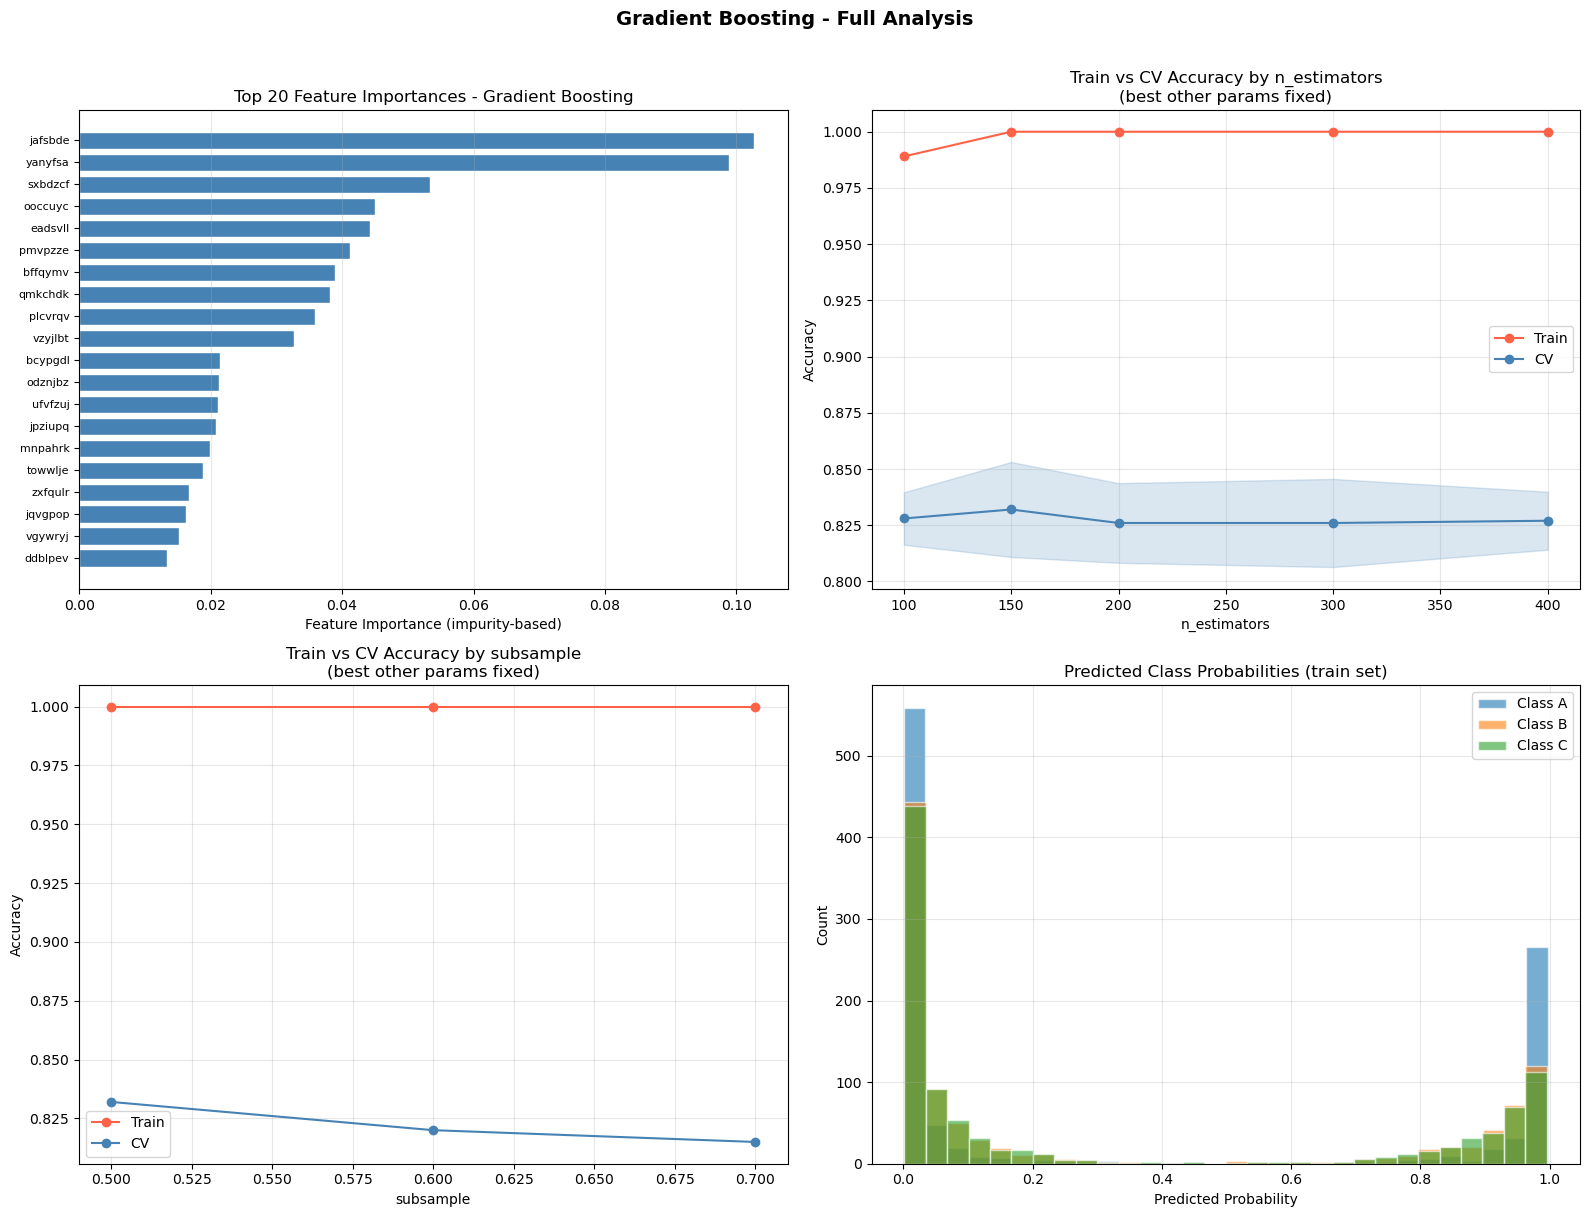


FINAL MODEL SUMMARY
Best hyperparameters:  {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 3, 'model__n_estimators': 150, 'model__subsample': 0.5}
k (SelectKBest):       50
Number of base models: 150
Train accuracy:        1.0000
CV accuracy (5-fold):  0.8320

Top 10 features:
  jafsbde: 0.1026
  yanyfsa: 0.0989
  sxbdzcf: 0.0533
  ooccuyc: 0.0450
  eadsvll: 0.0443
  pmvpzze: 0.0411
  bffqymv: 0.0390
  qmkchdk: 0.0382
  plcvrqv: 0.0359
  vzyjlbt: 0.0327


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# 1. GridSearch
# ------------------------------------------------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(f_classif, k=50)),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators':     [100, 150, 200, 300, 400],
    'model__learning_rate':    [0.05, 0.075, 0.1],
    'model__max_depth':        [3, 4],
    'model__subsample':        [0.5, 0.6, 0.7],
    'model__min_samples_leaf': [1, 2, 3]
}

grid = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# ------------------------------------------------------------
# 2. Resultados del GridSearch
# ------------------------------------------------------------
results_df = pd.DataFrame(grid.cv_results_)
print(f"\nTrain accuracy (best model): {results_df.loc[grid.best_index_, 'mean_train_score']:.4f}")
print(f"CV accuracy (best model):    {results_df.loc[grid.best_index_, 'mean_test_score']:.4f}")
print(f"Std CV (best model):         {results_df.loc[grid.best_index_, 'std_test_score']:.4f}")

# ------------------------------------------------------------
# 3. Feature importance
# ------------------------------------------------------------
best_model    = grid.best_estimator_.named_steps['model']
selector      = grid.best_estimator_.named_steps['selector']
preprocessor_ = grid.best_estimator_.named_steps['preprocessor']

# Nombres de features tras el preprocessor
num_feature_names = list(numeric_features)
try:
    cat_feature_names = list(
        preprocessor_.named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )
except:
    cat_feature_names = []

all_feature_names = np.array(num_feature_names + cat_feature_names)

# Features seleccionadas por SelectKBest
selected_indices  = selector.get_support(indices=True)
selected_names    = all_feature_names[selected_indices] if len(all_feature_names) > 0 else [f"feature_{i}" for i in selected_indices]

importances       = best_model.feature_importances_
sorted_idx        = np.argsort(importances)[::-1]

# Plot feature importance (top 20)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -- Plot 1: Feature importance top 20
ax = axes[0, 0]
top_n = 20
ax.barh(
    range(top_n),
    importances[sorted_idx[:top_n]][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_yticks(range(top_n))
ax.set_yticklabels([selected_names[i] if i < len(selected_names) else f"f{i}"
                    for i in sorted_idx[:top_n]][::-1], fontsize=8)
ax.set_xlabel("Feature Importance (impurity-based)")
ax.set_title("Top 20 Feature Importances - Gradient Boosting")
ax.grid(axis='x', alpha=0.3)

# -- Plot 2: CV accuracy vs n_estimators
ax = axes[0, 1]
best_lr    = grid.best_params_['model__learning_rate']
best_depth = grid.best_params_['model__max_depth']
best_sub   = grid.best_params_['model__subsample']
best_leaf  = grid.best_params_['model__min_samples_leaf']

mask = (
    (results_df['param_model__learning_rate']    == best_lr) &
    (results_df['param_model__max_depth']        == best_depth) &
    (results_df['param_model__subsample']        == best_sub) &
    (results_df['param_model__min_samples_leaf'] == best_leaf)
)
subset = results_df[mask].sort_values('param_model__n_estimators')
ax.plot(subset['param_model__n_estimators'], subset['mean_train_score'],
        'o-', label='Train', color='tomato')
ax.plot(subset['param_model__n_estimators'], subset['mean_test_score'],
        'o-', label='CV', color='steelblue')
ax.fill_between(
    subset['param_model__n_estimators'],
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='steelblue'
)
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs CV Accuracy by n_estimators\n(best other params fixed)")
ax.legend()
ax.grid(alpha=0.3)

# -- Plot 3: CV accuracy vs subsample
ax = axes[1, 0]
best_n = grid.best_params_['model__n_estimators']
mask2 = (
    (results_df['param_model__learning_rate']    == best_lr) &
    (results_df['param_model__max_depth']        == best_depth) &
    (results_df['param_model__n_estimators']     == best_n) &
    (results_df['param_model__min_samples_leaf'] == best_leaf)
)
subset2 = results_df[mask2].sort_values('param_model__subsample')
ax.plot(subset2['param_model__subsample'], subset2['mean_train_score'],
        'o-', label='Train', color='tomato')
ax.plot(subset2['param_model__subsample'], subset2['mean_test_score'],
        'o-', label='CV', color='steelblue')
ax.set_xlabel("subsample")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs CV Accuracy by subsample\n(best other params fixed)")
ax.legend()
ax.grid(alpha=0.3)

# -- Plot 4: Predicted class probabilities
ax = axes[1, 1]
proba = grid.predict_proba(X)
for i, cls in enumerate(grid.classes_):
    ax.hist(proba[:, i], bins=30, alpha=0.6, label=f"Class {cls}", edgecolor='white')
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Predicted Class Probabilities (train set)")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Gradient Boosting - Full Analysis", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("gb_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 4. Resumen final
# ------------------------------------------------------------
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Best hyperparameters:  {grid.best_params_}")
print(f"k (SelectKBest):       50")
print(f"Number of base models: {grid.best_params_['model__n_estimators']}")
print(f"Train accuracy:        {results_df.loc[grid.best_index_, 'mean_train_score']:.4f}")
print(f"CV accuracy (5-fold):  {grid.best_score_:.4f}")
print(f"\nTop 10 features:")
for i in sorted_idx[:10]:
    name = selected_names[i] if i < len(selected_names) else f"feature_{i}"
    print(f"  {name}: {importances[i]:.4f}")

In [ ]:

# ------------------------------------------------------------
# 10. Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cv_acc_mean", ascending=False)

display(results_df)

results_df.to_csv("gradient_boosting_manual_experiments.csv", index=False)

In [ ]:
# ------------------------------------------------------------
# 12. Final predictions
# ------------------------------------------------------------

best_model = grid.best_estimator_
best_model.fit(X, y)

preds = best_model.predict(X_test_final)

submission = df_test.copy()
submission[target_col] = preds

submission.to_csv("test_gradient_boosting_predictions.csv", index=False)